In [236]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In [127]:
DATA_PATH = "../../data/output_data/"
FIGURES_PATH = "../../data/figures/"
dataset = "hgsoc"
# Tools: BAMixChecker, CrossCheckFingerprints, HYSYS, NGSCheckmate, Vireo

# Vireo

In [ ]:
vireo_matrix = pd.read_csv(DATA_PATH + f"vireo/{dataset}/similarity_matrix.csv", index_col=0)

In [15]:
vireo_matrix.columns = [col.replace("_bulk_chunk_ribo.bam", "") for col in vireo_matrix.columns]
vireo_matrix.index = pd.Index([idx.replace("_bulk_chunk_ribo.bam", "") for idx in vireo_matrix.index])

In [123]:
# Order rows and columns
ordered_samples = sorted(vireo_matrix.columns)
vireo_matrix = vireo_matrix.loc[ordered_samples, ordered_samples]

In [124]:
vireo_matrix

,2251_bulk_chunk_ribo,2267_bulk_chunk_ribo,2283_bulk_chunk_ribo,2293_bulk_chunk_ribo,2380_bulk_chunk_ribo,2428_bulk_chunk_ribo,2467_bulk_chunk_ribo,2497_bulk_chunk_ribo
2251_bulk_chunk_ribo,0.000000,0.271493,0.285729,0.274827,0.265772,0.292903,0.310212,0.281027
2267_bulk_chunk_ribo,0.271493,0.000000,0.275595,0.259303,0.233221,0.284516,0.301841,0.269990
2283_bulk_chunk_ribo,0.285729,0.275595,0.000000,0.277229,0.270669,0.291544,0.306442,0.284192
2293_bulk_chunk_ribo,0.274827,0.259303,0.277229,0.000000,0.252863,0.271351,0.290953,0.279889
2380_bulk_chunk_ribo,0.265772,0.233221,0.270669,0.252863,0.000000,0.282191,0.298501,0.265449
2428_bulk_chunk_ribo,0.292903,0.284516,0.291544,0.271351,0.282191,0.000000,0.301771,0.298349
2467_bulk_chunk_ribo,0.310212,0.301841,0.306442,0.290953,0.298501,0.301771,0.000000,0.308719
2497_bulk_chunk_ribo,0.281027,0.269990,0.284192,0.279889,0.265449,0.298349,0.308719,0.000000


Text(0.5, 1.0, 'Vireo Similarity Matrix')

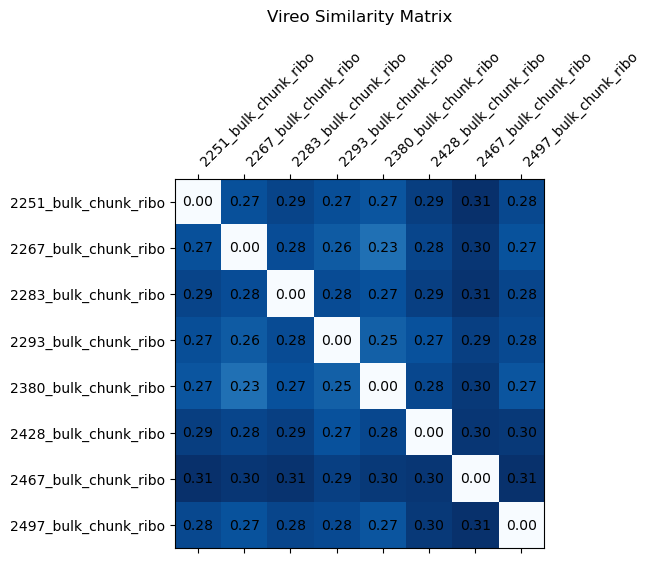

In [128]:
fig, ax = plt.subplots()
ax.matshow(vireo_matrix, cmap="Blues")

for (i, j), z in np.ndenumerate(vireo_matrix):
    ax.text(j, i, "{:.2f}".format(z), ha="center", va="center")


ax.set_xticks(np.arange(len(vireo_matrix.columns)))
ax.set_yticks(np.arange(len(vireo_matrix.index)))
ax.set_xticklabels(vireo_matrix.columns, rotation=45, ha="left")
ax.set_yticklabels(vireo_matrix.index)
ax.xaxis.set_label_position("top")
# ax.set_xlabel("Samples")
# ax.set_ylabel("Samples")
ax.set_title("Vireo Similarity Matrix", pad=20)

In [ ]:
# fig.savefig(FIGURES_PATH + f"{dataset}_vireo_similarity_matrix.png", bbox_inches="tight", dpi=300)
# fig.savefig(FIGURES_PATH + f"{dataset}_vireo_similarity_matrix.pdf", bbox_inches="tight", dpi=300)

# NGSCheckmate

In [227]:
ngscheckmate_df = pd.read_csv(DATA_PATH + f"ngscheckmate/{dataset}/output_all.txt", sep="\t", index_col=0, header=None)

In [228]:
ngscheckmate_dict = {
    x: 
    x.replace("_bulk_chunk_ribo_filtered_variants.vcf", "") 
    for x in list(set(ngscheckmate_df.index) | set(ngscheckmate_df[2]))
}
ngscheckmate_df.index = ngscheckmate_df.index.map(ngscheckmate_dict)
ngscheckmate_df[2] = ngscheckmate_df[2].map(ngscheckmate_dict)
ngscheckmate_df.columns = ["Matched", "Sample", "Binary", "Correlation"]

In [229]:
ngscheckmate_df.head()

,Matched,Sample,Binary,Correlation
0,,,,
2251_bulk_chunk_ribo,matched,2267_bulk_chunk_ribo,1.0,98.43
2251_bulk_chunk_ribo,matched,2283_bulk_chunk_ribo,1.0,96.39
2251_bulk_chunk_ribo,matched,2293_bulk_chunk_ribo,1.0,96.50
2251_bulk_chunk_ribo,matched,2380_bulk_chunk_ribo,1.0,99.27
2251_bulk_chunk_ribo,matched,2428_bulk_chunk_ribo,1.0,86.47


In [230]:
def long_df_to_matrix_ngscheckmate(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Correlation"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]/100
                matrix.at[x, y] = corr_value.values[0]/100

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [231]:
ngscheckmate_matrix = long_df_to_matrix_ngscheckmate(ngscheckmate_df)

In [232]:
ngscheckmate_matrix

,2251_bulk_chunk_ribo,2267_bulk_chunk_ribo,2283_bulk_chunk_ribo,2293_bulk_chunk_ribo,2380_bulk_chunk_ribo,2428_bulk_chunk_ribo,2467_bulk_chunk_ribo,2497_bulk_chunk_ribo
2251_bulk_chunk_ribo,NaN,0.9843,0.9639,0.9650,0.9927,0.8647,0.9179,0.9836
2267_bulk_chunk_ribo,0.9843,NaN,0.9639,0.9650,0.9843,0.8647,0.9179,0.9836
2283_bulk_chunk_ribo,0.9639,0.9639,NaN,0.9639,0.9639,0.8647,0.9179,0.9639
2293_bulk_chunk_ribo,0.9650,0.9650,0.9639,NaN,0.9650,0.8647,0.9179,0.9650
2380_bulk_chunk_ribo,0.9927,0.9843,0.9639,0.9650,NaN,0.8647,0.9179,0.9836
2428_bulk_chunk_ribo,0.8647,0.8647,0.8647,0.8647,0.8647,NaN,0.8647,0.8647
2467_bulk_chunk_ribo,0.9179,0.9179,0.9179,0.9179,0.9179,0.8647,NaN,0.9179
2497_bulk_chunk_ribo,0.9836,0.9836,0.9639,0.9650,0.9836,0.8647,0.9179,NaN


Text(0.5, 1.0, 'NGSCheckmate Correlation Matrix')

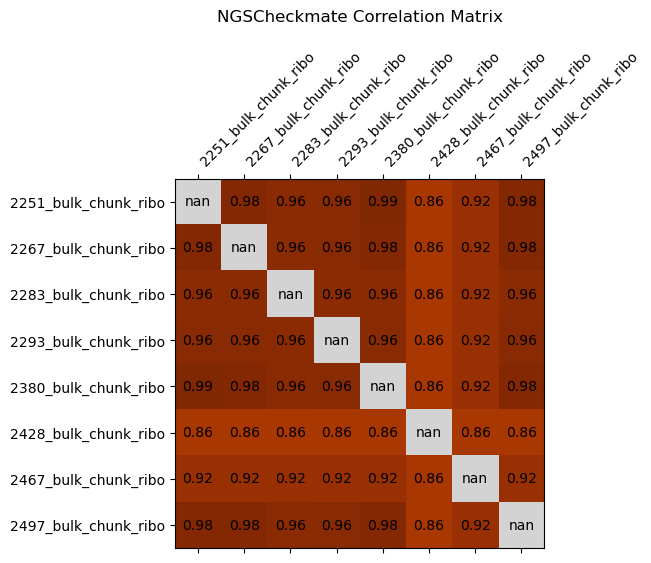

In [234]:
fig, ax = plt.subplots()
cmap = plt.cm.Oranges
cmap.set_bad(color="lightgray")
ax.matshow(ngscheckmate_matrix, cmap=cmap, vmin=0, vmax=1)

for (i, j), z in np.ndenumerate(ngscheckmate_matrix):
    ax.text(j, i, "{:.2f}".format(z), ha="center", va="center")


ax.set_xticks(np.arange(len(ngscheckmate_matrix.columns)))
ax.set_yticks(np.arange(len(ngscheckmate_matrix.index)))
ax.set_xticklabels(ngscheckmate_matrix.columns, rotation=45, ha="left")
ax.set_yticklabels(ngscheckmate_matrix.index)
ax.xaxis.set_label_position("top")
# ax.set_xlabel("Samples")
# ax.set_ylabel("Samples")
ax.set_title("NGSCheckmate Correlation Matrix", pad=20)

In [ ]:
# fig.savefig(FIGURES_PATH + f"{dataset}_ngscheckmate_correlation_matrix.png", bbox_inches="tight", dpi=300)
# fig.savefig(FIGURES_PATH + f"{dataset}_ngscheckmate_correlation_matrix.pdf", bbox_inches="tight", dpi=300)

# HYSYS

In [201]:
hysys_df = pd.read_csv(DATA_PATH + f"hysys/{dataset}/concordance_output.txt", sep="\t", index_col=0, header=None)

In [202]:
hysys_dict = {
    x: 
    x.replace("_bulk_chunk_ribo_filtered_variants.snps", "").replace("hgsoc/", "")
    for x in list(set(hysys_df.index) | set(hysys_df[1]))
}
hysys_df.index = hysys_df.index.map(hysys_dict)
hysys_df[1] = hysys_df[1].map(hysys_dict)
hysys_df.columns = ["Sample", "Concordance", "Size"]

In [203]:
hysys_df.head()

,Sample,Concordance,Size
0,,,
2251_bulk_chunk_ribo,2251_bulk_chunk_ribo,1.000,476338
2251_bulk_chunk_ribo,2267_bulk_chunk_ribo,0.201,721495
2251_bulk_chunk_ribo,2283_bulk_chunk_ribo,0.214,782726
2251_bulk_chunk_ribo,2293_bulk_chunk_ribo,0.194,744953
2251_bulk_chunk_ribo,2380_bulk_chunk_ribo,0.191,689732


In [204]:
def long_df_to_matrix_hysys(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Concordance"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [205]:
hysys_matrix = long_df_to_matrix_hysys(hysys_df)

In [206]:
hysys_matrix

,2251_bulk_chunk_ribo,2267_bulk_chunk_ribo,2283_bulk_chunk_ribo,2293_bulk_chunk_ribo,2380_bulk_chunk_ribo,2428_bulk_chunk_ribo,2467_bulk_chunk_ribo,2497_bulk_chunk_ribo
2251_bulk_chunk_ribo,1.000,0.201,0.214,0.194,0.191,0.199,0.191,0.227
2267_bulk_chunk_ribo,0.201,1.000,0.189,0.174,0.192,0.177,0.165,0.197
2283_bulk_chunk_ribo,0.214,0.189,1.000,0.188,0.179,0.203,0.189,0.212
2293_bulk_chunk_ribo,0.194,0.174,0.188,1.000,0.167,0.189,0.178,0.188
2380_bulk_chunk_ribo,0.191,0.192,0.179,0.167,1.000,0.162,0.151,0.185
2428_bulk_chunk_ribo,0.199,0.177,0.203,0.189,0.162,1.000,0.186,0.200
2467_bulk_chunk_ribo,0.191,0.165,0.189,0.178,0.151,0.186,1.000,0.192
2497_bulk_chunk_ribo,0.227,0.197,0.212,0.188,0.185,0.200,0.192,1.000


Text(0.5, 1.0, 'HYSYS Concordance Matrix')

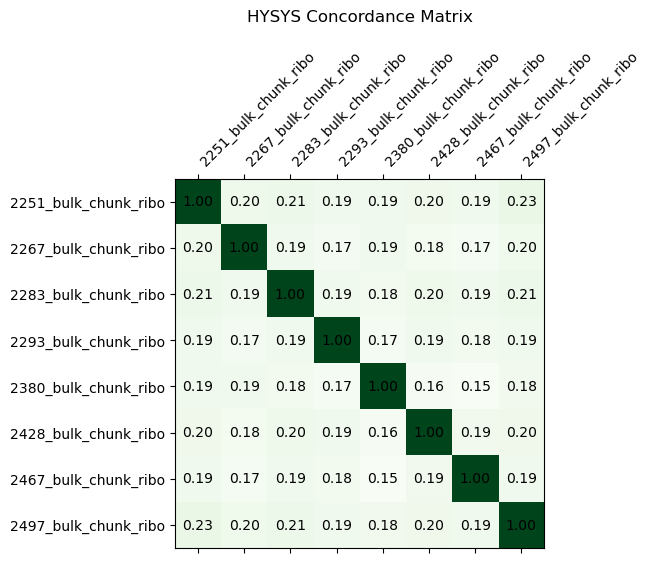

In [207]:
fig, ax = plt.subplots()
ax.matshow(hysys_matrix, cmap="Greens")

for (i, j), z in np.ndenumerate(hysys_matrix):
    ax.text(j, i, "{:.2f}".format(z), ha="center", va="center")


ax.set_xticks(np.arange(len(hysys_matrix.columns)))
ax.set_yticks(np.arange(len(hysys_matrix.index)))
ax.set_xticklabels(hysys_matrix.columns, rotation=45, ha="left")
ax.set_yticklabels(hysys_matrix.index)
ax.xaxis.set_label_position("top")
# ax.set_xlabel("Samples")
# ax.set_ylabel("Samples")
ax.set_title("HYSYS Concordance Matrix", pad=20)

In [ ]:
# fig.savefig(FIGURES_PATH + f"{dataset}_hysys_concordance_matrix.png", bbox_inches="tight", dpi=300)
# fig.savefig(FIGURES_PATH + f"{dataset}_hysys_concordance_matrix.pdf", bbox_inches="tight", dpi=300)

# CrossCheckFingerprints

In [208]:
fingerprints_df = pd.read_csv(DATA_PATH + f"fingerprints/{dataset}/crosscheck_metrics.txt", sep="\t", header=5)
fingerprints_df = fingerprints_df[["LEFT_SAMPLE", "RIGHT_SAMPLE", "LOD_SCORE", "RESULT"]]

In [209]:
fingerprints_dict = {
    x: 
    x.replace("_bulk_chunk_ribo.bam", "")
    for x in list(set(fingerprints_df["LEFT_SAMPLE"]) | set(fingerprints_df["RIGHT_SAMPLE"]))
}
fingerprints_df["LEFT_SAMPLE"] = fingerprints_df["LEFT_SAMPLE"].map(fingerprints_dict)
fingerprints_df["RIGHT_SAMPLE"] = fingerprints_df["RIGHT_SAMPLE"].map(fingerprints_dict)

In [210]:
fingerprints_df.head()

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,2251_bulk_chunk_ribo,2251_bulk_chunk_ribo,851.099061,EXPECTED_MATCH
1,2251_bulk_chunk_ribo,2467_bulk_chunk_ribo,-212.226323,EXPECTED_MISMATCH
2,2251_bulk_chunk_ribo,2283_bulk_chunk_ribo,-221.992840,EXPECTED_MISMATCH
3,2251_bulk_chunk_ribo,2267_bulk_chunk_ribo,-231.943011,EXPECTED_MISMATCH
4,2251_bulk_chunk_ribo,2293_bulk_chunk_ribo,-182.431811,EXPECTED_MISMATCH


In [211]:
def long_df_to_matrix_fingerprints(df):
    matrix = pd.DataFrame()

    for x in df["LEFT_SAMPLE"].unique():
        for y in df["RIGHT_SAMPLE"].unique():
            corr_value = df.loc[(df["LEFT_SAMPLE"] == x) & (df["RIGHT_SAMPLE"] == y), "LOD_SCORE"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [212]:
fingerprints_matrix = long_df_to_matrix_fingerprints(fingerprints_df)

In [213]:
fingerprints_matrix

,2251_bulk_chunk_ribo,2267_bulk_chunk_ribo,2283_bulk_chunk_ribo,2293_bulk_chunk_ribo,2380_bulk_chunk_ribo,2428_bulk_chunk_ribo,2467_bulk_chunk_ribo,2497_bulk_chunk_ribo
2251_bulk_chunk_ribo,851.099061,-231.943011,-221.992840,-182.431811,-153.799846,-184.218655,-212.226323,-251.537912
2267_bulk_chunk_ribo,-231.943011,722.187054,-201.161079,-170.474900,-181.048786,-160.745242,-209.946309,-190.730859
2283_bulk_chunk_ribo,-221.992840,-201.161079,856.252704,-178.916314,-180.205132,-196.369045,-199.528955,-190.885922
2293_bulk_chunk_ribo,-182.431811,-170.474900,-178.916314,669.926196,-116.489713,-173.365490,-175.432978,-144.848390
2380_bulk_chunk_ribo,-153.799846,-181.048786,-180.205132,-116.489713,630.655349,-158.636447,-143.325223,-126.826573
2428_bulk_chunk_ribo,-184.218655,-160.745242,-196.369045,-173.365490,-158.636447,793.301692,-193.176240,-185.456588
2467_bulk_chunk_ribo,-212.226323,-209.946309,-199.528955,-175.432978,-143.325223,-193.176240,845.807987,-212.703754
2497_bulk_chunk_ribo,-251.537912,-190.730859,-190.885922,-144.848390,-126.826573,-185.456588,-212.703754,860.099778


Text(0.5, 1.0, 'CrossCheckFingerprints LOD Score Matrix')

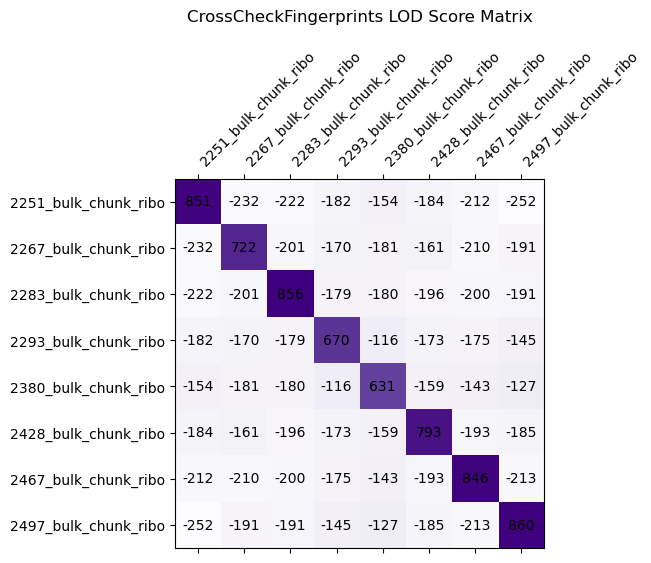

In [214]:
fig, ax = plt.subplots()
ax.matshow(fingerprints_matrix, cmap="Purples")

for (i, j), z in np.ndenumerate(fingerprints_matrix):
    ax.text(j, i, "{:.0f}".format(z), ha="center", va="center")


ax.set_xticks(np.arange(len(fingerprints_matrix.columns)))
ax.set_yticks(np.arange(len(fingerprints_matrix.index)))
ax.set_xticklabels(fingerprints_matrix.columns, rotation=45, ha="left")
ax.set_yticklabels(fingerprints_matrix.index)
ax.xaxis.set_label_position("top")
# ax.set_xlabel("Samples")
# ax.set_ylabel("Samples")
ax.set_title("CrossCheckFingerprints LOD Score Matrix", pad=20)

In [ ]:
# fig.savefig(FIGURES_PATH + f"{dataset}_fingerprints_lod_score_matrix.png", bbox_inches="tight", dpi=300)
# fig.savefig(FIGURES_PATH + f"{dataset}_fingerprints_lod_score_matrix.pdf", bbox_inches="tight", dpi=300)

# BAMixChecker

In [215]:
bamixchecker_df = pd.read_csv(DATA_PATH + f"bamixchecker/{dataset}/BAMixChecker/Total_result.txt", sep="\t", index_col=0, header=None)
bamixchecker_df.columns = ["Sample", "Concordance Rate", "Conclusion"]

In [216]:
bamixchecker_dict = {
    x: 
    x.replace("_bulk_chunk_ribo_filtered_rg.bam", "") 
    for x in list(set(bamixchecker_df.index) | set(bamixchecker_df["Sample"]))
}
bamixchecker_df.index = bamixchecker_df.index.map(bamixchecker_dict)
bamixchecker_df["Sample"] = bamixchecker_df["Sample"].map(bamixchecker_dict)

In [217]:
bamixchecker_df.head()

,Sample,Concordance Rate,Conclusion
0,,,
2380_bulk_chunk_ribo,2467_bulk_chunk_ribo,0.0,Unmatched
2380_bulk_chunk_ribo,2267_bulk_chunk_ribo,0.0,Unmatched
2380_bulk_chunk_ribo,2428_bulk_chunk_ribo,0.0,Unmatched
2380_bulk_chunk_ribo,2293_bulk_chunk_ribo,0.0,Unmatched
2380_bulk_chunk_ribo,2497_bulk_chunk_ribo,0.0,Unmatched


In [218]:
def long_df_to_matrix_bamixchecker(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Concordance Rate"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]
                matrix.at[x, y] = corr_value.values[0]

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [219]:
bamixchecker_matrix = long_df_to_matrix_bamixchecker(bamixchecker_df)

In [220]:
bamixchecker_matrix

,2251_bulk_chunk_ribo,2267_bulk_chunk_ribo,2283_bulk_chunk_ribo,2293_bulk_chunk_ribo,2380_bulk_chunk_ribo,2428_bulk_chunk_ribo,2467_bulk_chunk_ribo,2497_bulk_chunk_ribo
2251_bulk_chunk_ribo,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2267_bulk_chunk_ribo,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2283_bulk_chunk_ribo,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0
2293_bulk_chunk_ribo,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0
2380_bulk_chunk_ribo,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0
2428_bulk_chunk_ribo,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0
2467_bulk_chunk_ribo,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
2497_bulk_chunk_ribo,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


Text(0.5, 1.0, 'BAMixChecker Concordance Matrix')

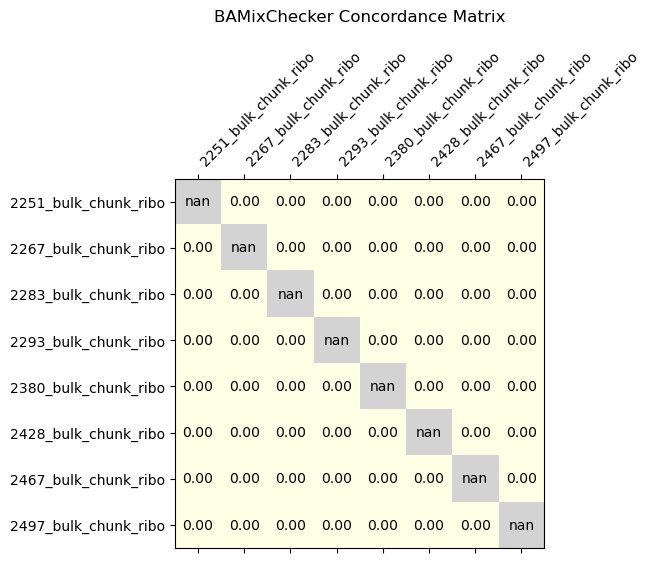

In [224]:
fig, ax = plt.subplots()
cmap = plt.cm.YlOrBr
cmap.set_bad(color="lightgray")

ax.matshow(bamixchecker_matrix, cmap=cmap, vmin=0, vmax=1)

for (i, j), z in np.ndenumerate(bamixchecker_matrix):
    ax.text(j, i, "{:.2f}".format(z), ha="center", va="center")


ax.set_xticks(np.arange(len(bamixchecker_matrix.columns)))
ax.set_yticks(np.arange(len(bamixchecker_matrix.index)))
ax.set_xticklabels(bamixchecker_matrix.columns, rotation=45, ha="left")
ax.set_yticklabels(bamixchecker_matrix.index)
ax.xaxis.set_label_position("top")
# ax.set_xlabel("Samples")
# ax.set_ylabel("Samples")
ax.set_title("BAMixChecker Concordance Matrix", pad=20)

In [ ]:
# fig.savefig(FIGURES_PATH + f"{dataset}_bamixchecker_concordance_matrix.png", bbox_inches="tight", dpi=300)
# fig.savefig(FIGURES_PATH + f"{dataset}_bamixchecker_concordance_matrix.pdf", bbox_inches="tight", dpi=300)

# Tool comparison

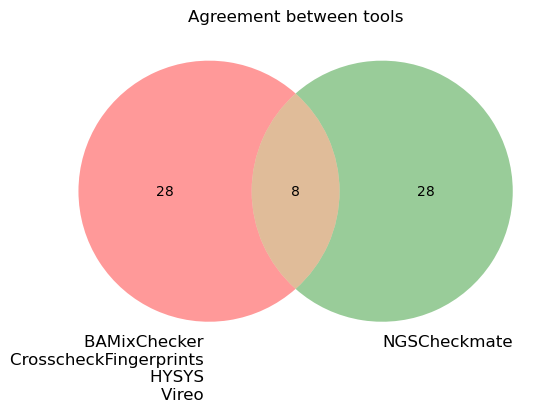

In [243]:
venn2(subsets=(28, 28, 8), set_labels=('BAMixChecker \nCrosscheckFingerprints \nHYSYS \nVireo ', 'NGSCheckmate'))
plt.title("Agreement between tools")
plt.show()